<a href="https://colab.research.google.com/github/baisesreevidya-sys/FUTURE_DS_01/blob/main/Task2_Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

subscriptions = pd.read_csv('/content/ravenstack_subscriptions.csv')

subscriptions.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [2]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object
 2   start_date         5000 non-null   object
 3   end_date           486 non-null    object
 4   plan_tier          5000 non-null   object
 5   seats              5000 non-null   int64 
 6   mrr_amount         5000 non-null   int64 
 7   arr_amount         5000 non-null   int64 
 8   is_trial           5000 non-null   bool  
 9   upgrade_flag       5000 non-null   bool  
 10  downgrade_flag     5000 non-null   bool  
 11  churn_flag         5000 non-null   bool  
 12  billing_frequency  5000 non-null   object
 13  auto_renew_flag    5000 non-null   bool  
dtypes: bool(5), int64(3), object(6)
memory usage: 376.1+ KB


In [3]:
subscriptions.describe()

,seats,mrr_amount,arr_amount
count,5000.000000,5000.000000,5000.000000
mean,29.852000,2267.749400,27212.992800
std,23.089771,3421.375348,41056.504178
min,1.000000,0.000000,0.000000
25%,14.000000,285.000000,3420.000000
50%,24.000000,931.000000,11172.000000
75%,40.000000,2786.000000,33432.000000
max,189.000000,33830.000000,405960.000000


In [4]:
subscriptions.isnull().sum()

,0
subscription_id,0
account_id,0
start_date,0
end_date,4514
plan_tier,0
seats,0
mrr_amount,0
arr_amount,0
is_trial,0
upgrade_flag,0


In [5]:
subscriptions['churn_flag'].value_counts()

,count
churn_flag,
False,4514
True,486


In [6]:
churn_rate = (subscriptions['churn_flag'].sum() / len(subscriptions)) * 100

print("Churn Rate:", round(churn_rate, 2), "%")

Churn Rate: 9.72 %


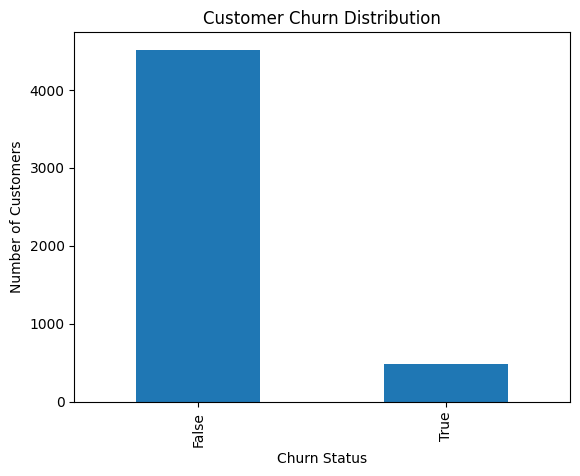

In [7]:
import matplotlib.pyplot as plt

subscriptions['churn_flag'].value_counts().plot(
    kind='bar',
    title='Customer Churn Distribution'
)

plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

In [8]:
subscriptions.groupby('plan_tier')['churn_flag'].sum()

,churn_flag
plan_tier,
Basic,152
Enterprise,172
Pro,162


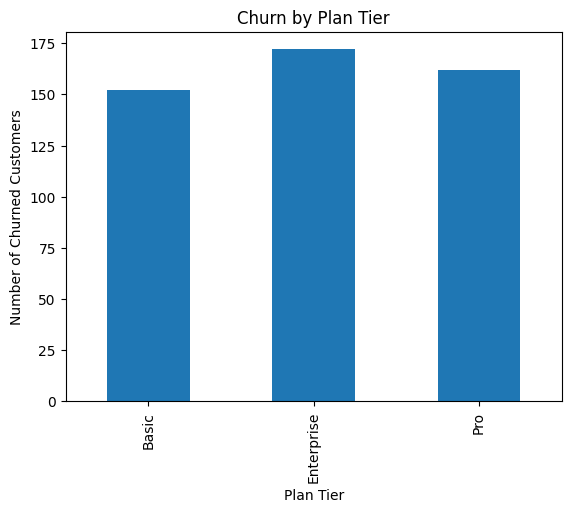

In [9]:
import matplotlib.pyplot as plt

subscriptions.groupby('plan_tier')['churn_flag'].sum().plot(
    kind='bar',
    title='Churn by Plan Tier'
)

plt.xlabel('Plan Tier')
plt.ylabel('Number of Churned Customers')
plt.show()

In [10]:
subscriptions.groupby('plan_tier')['mrr_amount'].mean()

,mrr_amount
plan_tier,
Basic,474.679775
Enterprise,4917.713871
Pro,1256.769552


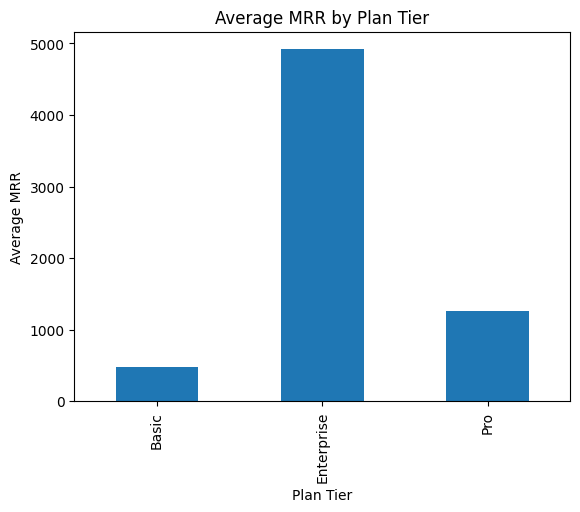

In [11]:
import matplotlib.pyplot as plt

subscriptions.groupby('plan_tier')['mrr_amount'].mean().plot(
    kind='bar',
    title='Average MRR by Plan Tier'
)

plt.xlabel('Plan Tier')
plt.ylabel('Average MRR')
plt.show()

In [12]:
subscriptions['billing_frequency'].value_counts()

,count
billing_frequency,
monthly,2539
annual,2461


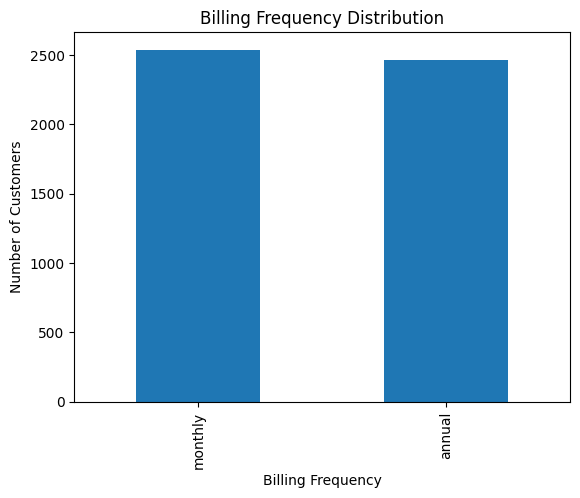

In [13]:
import matplotlib.pyplot as plt

subscriptions['billing_frequency'].value_counts().plot(
    kind='bar',
    title='Billing Frequency Distribution'
)

plt.xlabel('Billing Frequency')
plt.ylabel('Number of Customers')
plt.show()

In [14]:
subscriptions['auto_renew_flag'].value_counts()

,count
auto_renew_flag,
True,4005
False,995


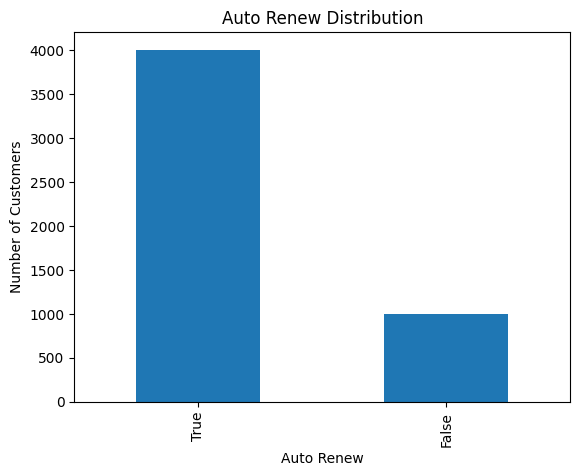

In [15]:
import matplotlib.pyplot as plt

subscriptions['auto_renew_flag'].value_counts().plot(
    kind='bar',
    title='Auto Renew Distribution'
)

plt.xlabel('Auto Renew')
plt.ylabel('Number of Customers')
plt.show()

In [16]:
# Business Insights

# 1. Overall churn rate is 9.72%, indicating good customer retention.
# 2. Enterprise plan generates the highest average monthly revenue.
# 3. Enterprise plan also has the highest number of churned customers.
# 4. Monthly and Annual billing customers are almost equally distributed.
# 5. Most customers (4005) have Auto Renew enabled, showing strong customer loyalty.
# 6. Reducing churn in Enterprise customers can significantly improve company revenue.

In [17]:
subscriptions.groupby('is_trial')['churn_flag'].sum()

,churn_flag
is_trial,
False,408
True,78


In [18]:
print("Upgrade Customers:")
print(subscriptions['upgrade_flag'].value_counts())

print("\nDowngrade Customers:")
print(subscriptions['downgrade_flag'].value_counts())

Upgrade Customers:
upgrade_flag
False    4471
True      529
Name: count, dtype: int64

Downgrade Customers:
downgrade_flag
False    4782
True      218
Name: count, dtype: int64


In [19]:
# Final Business Insights

# 1. Overall churn rate is 9.72%, indicating strong customer retention.
# 2. Enterprise plan generates the highest average monthly revenue (MRR).
# 3. Enterprise plan also has the highest churn count, so retaining these customers is important.
# 4. Monthly and Annual billing customers are almost equally distributed.
# 5. Most customers (4005) have Auto Renew enabled, showing good customer loyalty.
# 6. Trial users have lower churn (78) compared to paid users (408).
# 7. 529 customers upgraded their plans, while only 218 downgraded, indicating healthy customer growth.
# 8. Reducing churn among Enterprise customers can significantly increase company revenue.

In [20]:
subscriptions.groupby('auto_renew_flag')['churn_flag'].sum()

,churn_flag
auto_renew_flag,
False,96
True,390


In [21]:
subscriptions.groupby('plan_tier')['is_trial'].sum()

,is_trial
plan_tier,
Basic,246
Enterprise,273
Pro,259


In [22]:
subscriptions.groupby('plan_tier')['seats'].mean()

,seats
plan_tier,
Basic,29.570537
Enterprise,29.369704
Pro,30.617313


In [23]:
subscriptions.groupby('plan_tier')['arr_amount'].mean()

,arr_amount
plan_tier,
Basic,5696.157303
Enterprise,59012.566454
Pro,15081.234627


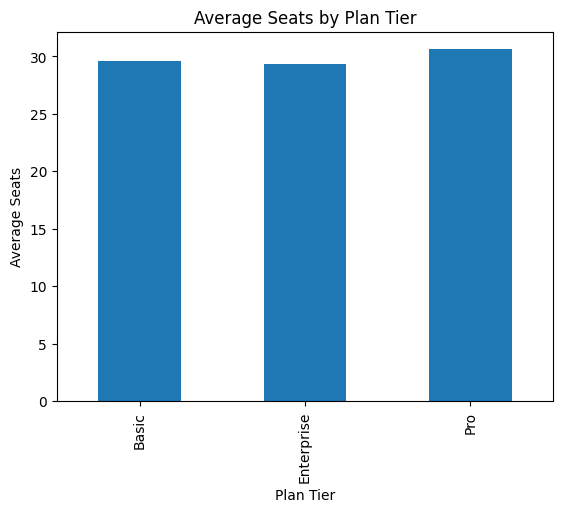

In [24]:
import matplotlib.pyplot as plt

subscriptions.groupby('plan_tier')['seats'].mean().plot(
    kind='bar',
    title='Average Seats by Plan Tier'
)

plt.xlabel('Plan Tier')
plt.ylabel('Average Seats')
plt.show()

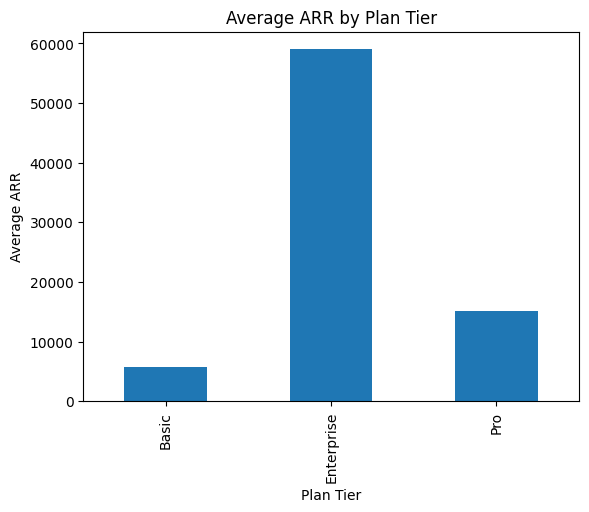

In [25]:
subscriptions.groupby('plan_tier')['arr_amount'].mean().plot(
    kind='bar',
    title='Average ARR by Plan Tier'
)

plt.xlabel('Plan Tier')
plt.ylabel('Average ARR')
plt.show()

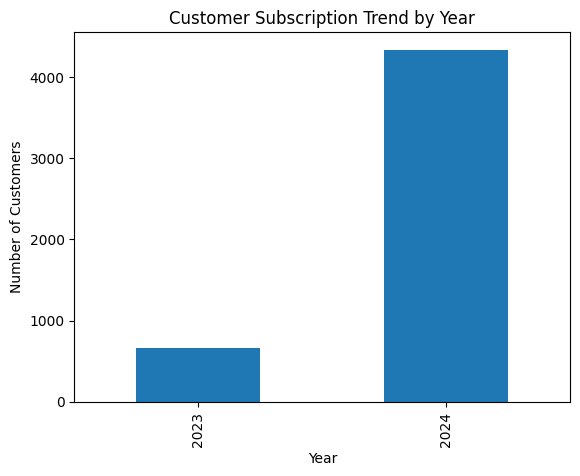

In [26]:
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])

subscriptions['start_date'].dt.year.value_counts().sort_index().plot(
    kind='bar',
    title='Customer Subscription Trend by Year'
)

import matplotlib.pyplot as plt
plt.xlabel('Year')
plt.ylabel('Number of Customers')
plt.show()

In [27]:
subscriptions[['plan_tier','billing_frequency','auto_renew_flag','churn_flag']].groupby(
    ['plan_tier','billing_frequency','auto_renew_flag']
).agg({'churn_flag':'sum'})

churn_flag
plan_tier  billing_frequency auto_renew_flag            
Basic      annual            False                    18
                             True                     58
           monthly           False                    21
                             True                     55
Enterprise annual            False                    14
                             True                     63
           monthly           False                    16
                             True                     79
Pro        annual            False                    16
                             True                     78
           monthly           False                    11
                             True                     57